# DATA PREPARATION

In [6]:
# INITIATION: PYTHON AND DISPLAY

# Import libraries
import pandas as pd #
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt #charts
import seaborn as sns #charts
from packages.pivot_utils import create_pivot_ui #This is my own customised Pivot Table Function

# For better visibility
from IPython.display import display, HTML

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))

# Set the option to display all columns
pd.set_option('display.max_columns', None)

# Set the option to display all rows
pd.set_option('display.max_rows', None)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))

In [7]:
# FILE LOAD

# Read the Excel file into a DataFrame
df_filter = pd.read_excel('2000 Analysis Python CHANGED.xlsx', decimal=',')
display (df_filter.head())

,2023,2022,2021,2020,2019,Name,GPW,Age (KRS),Business age,Business age?,Foreign branches,REGON,KRS,NIP,Legal form,PKD,PKD Opis,Sector 500,Sector,Country,Owner Type,S/J,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,BS,Fixed Assets,Current Assets,Equity,Liabilities,Remove,Comments,PKD_1,PKD_1 Description,PKD_2,PKD_2 Description,Digital intensity,Export as % of Sales,ROS,ROA,ROE,P/F,BS_Strength,Human_Capital,GVA,Productivity,Hint25,Hint50,HGX,HGX%,SGrowth_2023_2019,LSGrowth_2023_2019,RSGrowth_2023_2019,LRSGrowth_2023_2019,Annualised_Growth,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,SGrowth_2,SGrowth_1,GVAGrowth_2023_2019,EGrowth_2023_2019,LEGrowth_2023_2019,Annualised_EGrowth,Drop_Employment,EGrowth_3,EGrowth_2,PGrowth_2023_2019,Starting_Profit,Starting_INT,Starting_BS_Strength,Starting_Size_ln,Starting_Human_Capital,Starting_GVA,Starting_Prod
0,"2,00","2,00","3,00","2,00",2,"Jeronimo Martins Polska SA, Kostrzyn",NaN,1995,NaN,"2 004,00",NaN,630303023,222483,7791011327,SA,4719,Pozostała sprzedaż detaliczna prowadzona w nie...,Handel detaliczny,handel detaliczny,NaN,500,J,2019,"55 573 747,04","2 800 737,00","2 733 767,00","2 241 447,00","1 052 710,00","0,00","68 159,00","3 641 448,39","15 387 833,00","8 356 124,00","7 031 709,00","3 469 188,00","11 918 644,11",NaN,NaN,G,Wholesale and Retail Trade; Repair of Motor Ve...,47,"RETAIL TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high,"0,00","0,04","0,15","0,65",F,"0,23","53,43","6 442 185,39","94,52",Exp<25,Exp<50,Decreased Export Intensity,"0,00","76,38","0,57","27,81","0,25","15,24",No,No,No,2.Stable,Growing,"4 394 364,76","16,33","0,15","3,85",No,2.Hiring,Hiring,"42,15","0,04","0,00","0,23","17,83","53,43","6 442 185,39","94,52"
1,"2,00","2,00","3,00","2,00",2,"Jeronimo Martins Polska SA, Kostrzyn",NaN,1995,NaN,"2 004,00",NaN,630303023,222483,7791011327,SA,4719,Pozostała sprzedaż detaliczna prowadzona w nie...,Handel detaliczny,handel detaliczny,NaN,500,J,2020,"61 216 804,38","3 172 358,00","3 025 772,20","2 443 206,00","1 061 103,00","0,00","70 750,00","4 118 504,95","17 223 467,72","8 296 193,33","8 927 274,39","3 672 480,00","13 550 987,33",NaN,NaN,G,Wholesale and Retail Trade; Repair of Motor Ve...,47,"RETAIL TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high,"0,00","0,04","0,14","0,67",F,"0,21","58,21","7 290 862,95","103,05",Exp<25,Exp<50,Decreased Export Intensity,"0,00","76,38","0,57","27,81","0,25","15,24",No,No,No,2.Stable,Growing,"4 394 364,76","16,33","0,15","3,85",No,2.Hiring,Hiring,"42,15","0,04","0,00","0,23","17,83","53,43","6 442 185,39","94,52"
2,"2,00","2,00","3,00","2,00",2,"Jeronimo Martins Polska SA, Kostrzyn",NaN,1995,NaN,"2 004,00",NaN,630303023,222483,7791011327,SA,4719,Pozostała sprzedaż detaliczna prowadzona w nie...,Handel detaliczny,handel detaliczny,NaN,500,J,2021,"68 246 695,47","3 521 716,00","3 552 205,00","2 866 384,00","1 136 276,00","0,00","74 350,50","4 547 738,00","19 423 898,20","8 568 761,60","10 855 136,60","4 098 782,00","15 325 116,01",NaN,NaN,G,Wholesale and Retail Trade; Repair of Motor Ve...,47,"RETAIL TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high,"0,00","0,04","0,15","0,70",F,"0,21","61,17","8 069 454,00","108,53",Exp<25,Exp<50,Decreased Export Intensity,"0,00","76,38","0,57","27,81","0,25","15,24",No,No,No,2.Stable,Growing,"4 394 364,76","16,33","0,15","3,85",No,2.Hiring,Hiring,"42,15","0,04","0,00","0,23","17,83","53,43","6 442 185,39","94,52"
3,"2,00","2,00","3,00","2,00",2,"Jeronimo Martins Polska SA, Kostrzyn",NaN,1995,NaN,"2 004,00",NaN,630303023,222483,7791011327,SA,4719,Pozostała sprzedaż detaliczna prowadzona w nie...,Handel detaliczny,handel detaliczny,NaN,500,J,2022,"85 034 775,00","4 109 337,00","4 254 158,00","3 414 175,00","1 207 337,60","0,00","77 726,70","5 186 427,00","23 866 577,00","10 897 620,00","12 968 957,00","4 653 067,00","19 213 509,11",NaN,NaN,G,Wholesale and Retail Trade; Repair of Motor Ve...,47,"RETAIL TRADE, EXCEPT OF MOTOR VEHICLES",Medium-high,"0,00","0,04",

# DESCRIPTIVE ANALYSIS

In [8]:
create_pivot_ui(df_filter, 
                default_index=['SGrowth_2'], 
                default_columns='P/F',            
                default_values='Sales',             
                default_filter_column='Year',       
                default_filter_value=2023)

Dropdown(description='Filter by Year:', index=5, options=(None, 2019, 2020, 2021, 2022, 2023), value=2023)

SelectMultiple(description='Row', index=(64,), options=('2023', '2022', '2021', '2020', '2019', 'Name', 'GPW',…

Dropdown(description='Columns', index=47, options=('2023', '2022', '2021', '2020', '2019', 'Name', 'GPW', 'Age…

Dropdown(description='Values', index=12, options=('2023', '2022', '2021', '2020', '2019', 'Business age', 'Bus…

Dropdown(description='Aggregation', index=2, options=('sum', 'mean', 'count', 'Percentage of Total', 'Percenta…

...

Dropdown(description='Sort by Row', options=('Total', 'F', 'P', 'Total'), value='Total')

Dropdown(description='Row Sort', index=2, options=('Ascending', 'Descending', 'None'), value='None')

Button(button_style='success', description='Export to Excel', style=ButtonStyle(), tooltip='Click to export th…

Output()

Output()

In [9]:
# Filter for years 2019 and 2023
df_years = df_filter[df_filter['Year'].isin([2019, 2023])]

# Pivot with both Company and Sector as index
pivot = df_years.pivot(index=['Name', 'Sector'], columns='Year', values='Employment')

# Calculate employment change
pivot['Employment_Change'] = pivot[2023] - pivot[2019]

# Step 1: Calculate the sector-level sum
employment_change_by_sector = pivot.groupby('Sector')['Employment_Change'].sum().sort_values(ascending=False)

# Step 2: Add a total row
employment_change_by_sector.loc['TOTAL'] = employment_change_by_sector.sum()

# Step 3: Display
display(employment_change_by_sector)

Sector
budownictwo                    69 707,46
handel detaliczny              33 644,00
górnictwo i hutnictwo          33 286,00
ochrona zdrowia i farmacja     23 480,36
żywność                        12 189,20
media, telekomunkacja, IT       9 736,67
usługi                          9 056,68
chemia                          2 862,82
paliwa                            823,06
motoryzacja                       816,76
handle detaliczny                 507,00
handel hurtowy                 -2 404,87
energetyka                    -10 453,50
transport                    -122 033,79
produkcja                    -242 768,70
TOTAL                        -181 550,84
Name: Employment_Change, dtype: float64

In [10]:
# Grouping by the Growth_Category
grouped_data = df_filter[df_filter['Year'] == 2023].groupby('SGrowth_2', observed=False).size()
display(grouped_data)

SGrowth_2
0.Stressed       245
1.Declining      670
2.Stable         707
3.High Growth    188
dtype: int64

In [13]:
pivot_growth = df_filter.loc[(df_filter['Year'] == 2023) & (df_filter['Hint25'] == 'Exp<25')].pivot_table(
    index=['SGrowth_2', 'Hint25'], 
    columns='P/F', 
    values='Sales', 
    aggfunc='count', 
    observed=False, 
    margins=True  # Adds totals
)

display (pivot_growth)


pivot_strength = df_filter[df_filter['Year'] == 2023].pivot_table(
    index=['SGrowth_2','Hint25'], 
    columns='P/F', 
    values='Starting_BS_Strength', 
    observed=False, 
    margins=True #margins adds totals
)
display (pivot_strength)


,P/F,F,P,All
SGrowth_2,Hint25,,,
0.Stressed,Exp<25,66,84,150
1.Declining,Exp<25,146,223,369
2.Stable,Exp<25,167,247,414
3.High Growth,Exp<25,36,85,121
All,,415,639,1054


P/F                     F    P  All
SGrowth_2     Hint25               
0.Stressed    Exp<25 0,28 0,35 0,32
              Exp>25 0,38 0,41 0,40
1.Declining   Exp<25 0,39 0,38 0,38
              Exp>25 0,50 0,49 0,50
2.Stable      Exp<25 0,42 0,40 0,41
              Exp>25 0,50 0,49 0,49
3.High Growth Exp<25 0,38 0,35 0,36
              Exp>25 0,44 0,38 0,41
All                  0,44 0,41 0,42

In [14]:
# Calculate mean

mean = df_filter[df_filter['Year'] == 2023]['Starting_BS_Strength'].mean(skipna=True)

mean2019 = df_filter[df_filter['Year'] == 2019]['Starting_BS_Strength'].mean(skipna=True)

mean2 = df_filter[df_filter['Year'] == 2023]['BS_Strength'].mean(skipna=True)

mean20192 = df_filter[df_filter['Year'] == 2019]['BS_Strength'].mean(skipna=True)

print (mean, mean2019)

print (mean2, mean20192)

0.4200568445732775 0.4200568445732775
0.44603720425038296 0.4200568445732775


In [15]:
#### Filter the dataframe for the year 2023 and Owner Type 400
filtered_data = df_filter[(df_filter['Year'] == 2023) & (df_filter['Owner Type'] == 400)]

# Group by Growth_Category and count the occurrences in each group
grouped_data = filtered_data.groupby('SGrowth_2', observed=False).size()

# Display the result
print(grouped_data)

SGrowth_2
0.Stressed        99
1.Declining      257
2.Stable         307
3.High Growth     85
dtype: int64


In [16]:
sns.set(style="whitegrid", palette="pastel")

# 🔧 Single % growth boxplot with log Y-axis
def plot_growth_boxplot(
    df,
    category,
    growth='RSGrowth_2023_2019',
    winsorize=True,
    return_table=False,
    save=False,
    filename="growth_boxplot.png",
    sort_by='median'
):
    df_plot = df[[category, growth]].dropna().copy()

    if winsorize:
        lower = df_plot[growth].quantile(0.01)
        upper = df_plot[growth].quantile(0.99)
        df_plot[growth] = np.clip(df_plot[growth], lower, upper)
        
    

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x=category, y=growth, data=df_plot, ax=ax)

    ax.set_yscale('log')
    ax.set_title(f"% Growth by {category} [Log Y-Axis]")
    ax.set_ylabel("% Growth (log scale)")
    ax.set_xlabel("")

    # Summary table
    summary = df_plot.groupby(category)[growth].agg(['mean', 'median', 'std', 'count']).round(2)
    x_order = [tick.get_text() for tick in ax.get_xticklabels()]
    summary = summary.reindex(x_order)
    summary = summary.rename(index=str, columns={
        'mean': 'Mean % Growth',
        'median': 'Median % Growth',
        'std': 'Std Dev',
        'count': 'Count'
    })
    summary_t = summary.T

    # Table under chart
    plt.table(
        cellText=summary_t.values,
        colLabels=summary_t.columns,
        rowLabels=summary_t.index,
        cellLoc='center',
        rowLoc='center',
        loc='bottom',
        bbox=[0.0, -0.5, 1.0, 0.4]
    )

    plt.subplots_adjust(bottom=0.45)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

    if return_table:
        return summary


# 🔁 Batch version for multiple categories
def plot_growth_boxplots_batch(
    df,
    categories,
    growth='RSGrowth_2023_2019',
    winsorize=True,
    save_all=False,
    save_prefix="growth_",
    save_format="png",
    return_tables=False,
    export_excel=False,
    excel_filename="growth_summary_tables.xlsx"
):
    all_tables = {}

    for cat in categories:
        safe_name = str(cat).replace("/", "_").replace(" ", "_")
        filename = f"{save_prefix}{safe_name}.{save_format}" if save_all else None

        table = plot_growth_boxplot(
            df=df,
            category=cat,
            growth=growth,
            winsorize=winsorize,
            return_table=True,
            save=save_all,
            filename=filename
        )

        if return_tables:
            all_tables[cat] = table

    if export_excel and return_tables:
        with pd.ExcelWriter(excel_filename) as writer:
            for cat, tbl in all_tables.items():
                sheet_name = str(cat).replace("/", "_")[:31]
                tbl.to_excel(writer, sheet_name=sheet_name)

    if return_tables:
        return all_tables


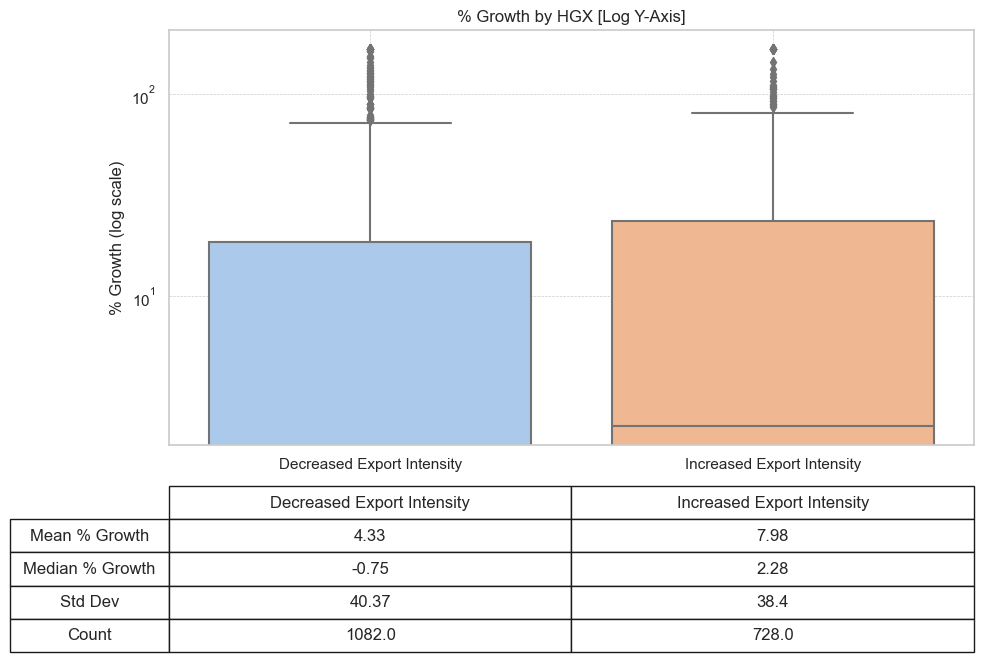

In [17]:
# Run a one-off chart
plot_growth_boxplot(df_filter[df_filter['Year'] == 2023], 'HGX')

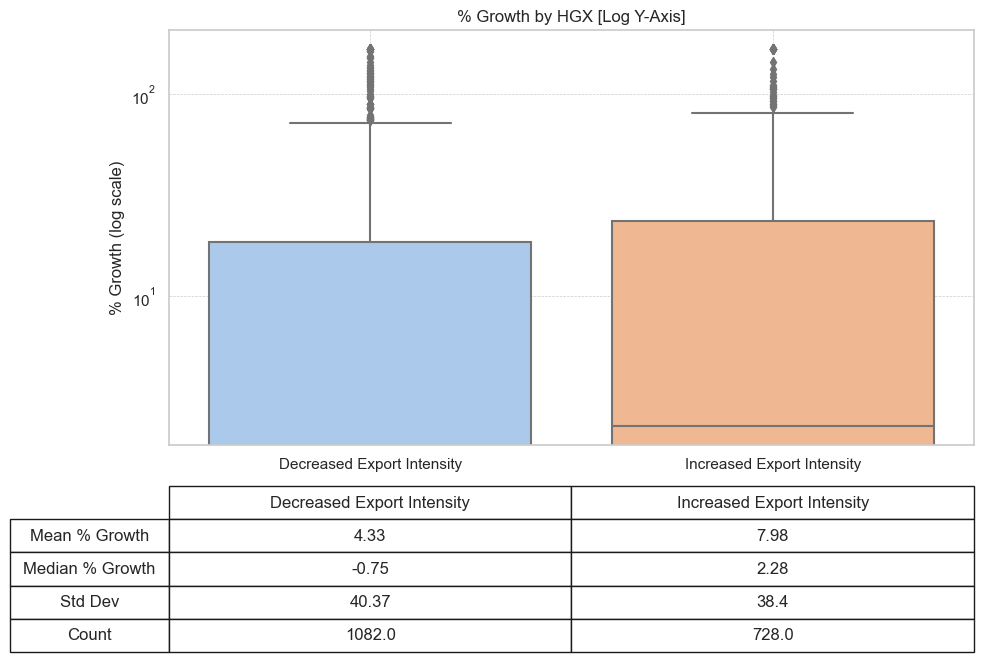

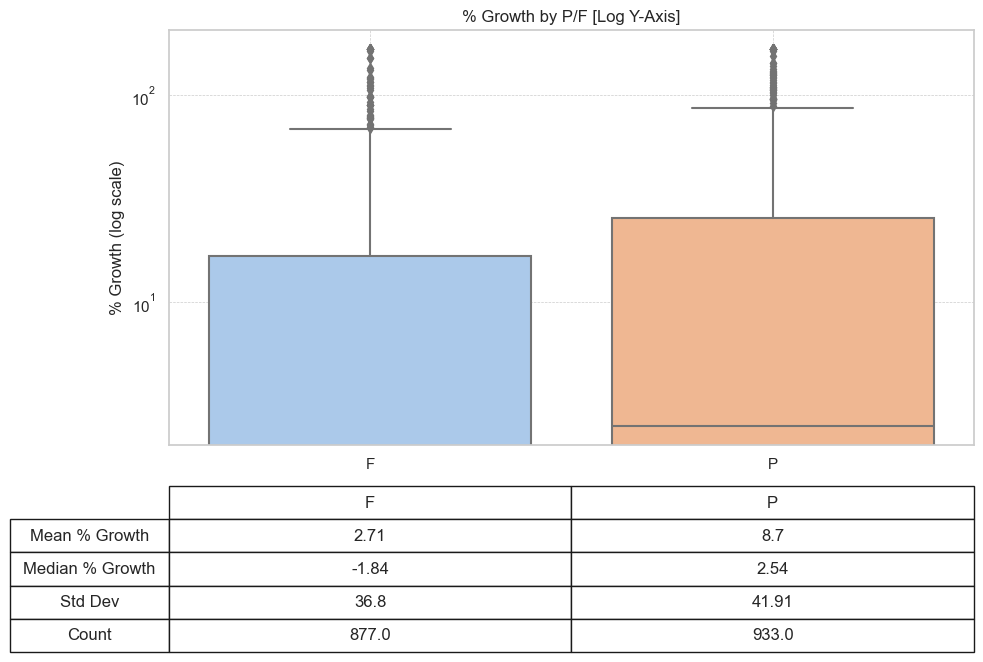

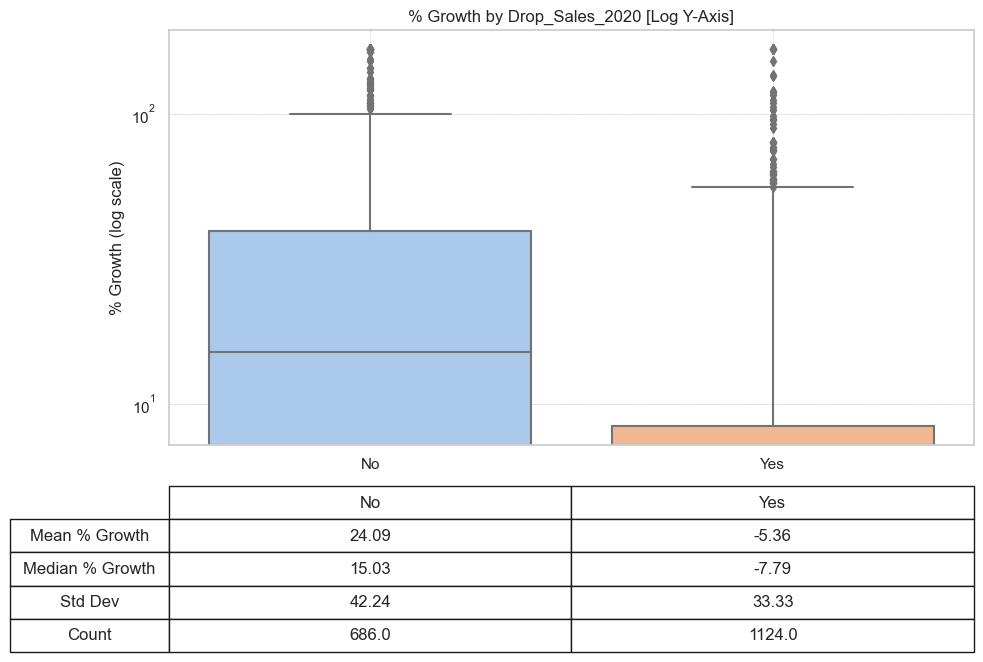

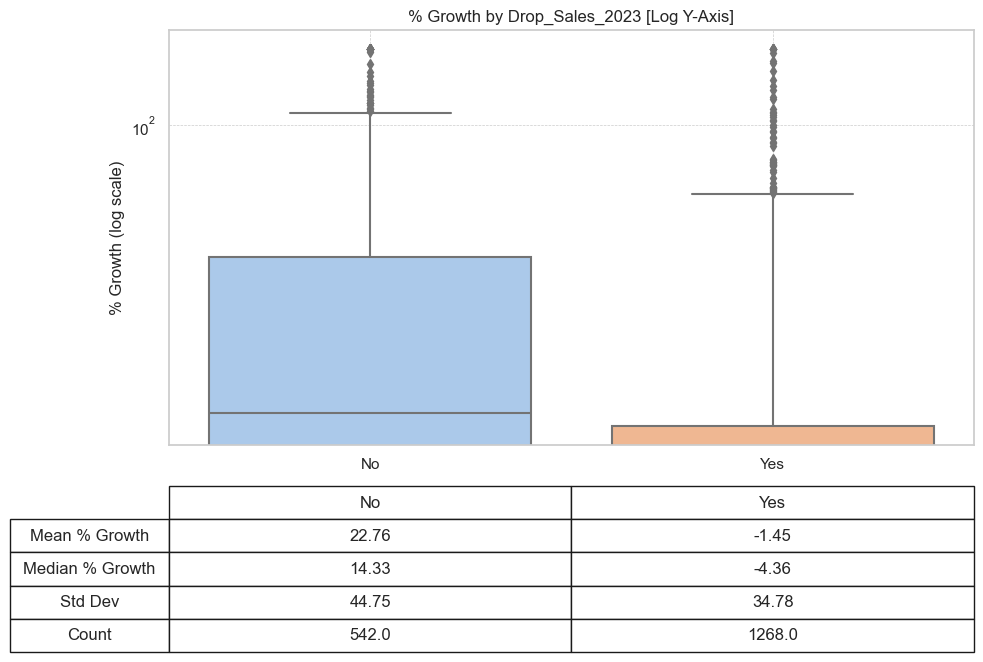

In [18]:
# Batch plots + Excel export
plot_growth_boxplots_batch(
    df=df_filter[df_filter['Year'] == 2023],
    categories=['HGX', 'P/F', 'Drop_Sales_2020', 'Drop_Sales_2023'],
    save_all=True,
    export_excel=True,
    excel_filename="summary_growth_clean.xlsx"
)

In [27]:
sns.set(style="whitegrid", palette="pastel")


# 🔧 SINGLE: With optional hue column
def plot_growth_barchart(
    df,
    group_col,
    growth_col='RSGrowth_2023_2019',
    hue_col=None,
    threshold=20,
    sort_by='median',
    winsorize=True,
    save=False,
    filename="growth_bar_chart.png",
    log_y=False
):
    use_cols = [group_col, growth_col] + ([hue_col] if hue_col else [])
    df = df[use_cols].dropna().copy()

    # Group small categories
    counts = df[group_col].value_counts()
    df['Group'] = df[group_col].apply(lambda x: x if counts[x] >= threshold else "Other (<20 firms)")

    if winsorize:
        lower = df[growth_col].quantile(0.01)
        upper = df[growth_col].quantile(0.99)
        df[growth_col] = np.clip(df[growth_col], lower, upper)

    groupby_cols = ['Group'] + ([hue_col] if hue_col else [])
    summary = df.groupby(groupby_cols)[growth_col].agg(['mean', 'median', 'std', 'count']).round(2).reset_index()

    # Pick sort column
    sort_col = 'Median % Growth' if sort_by == 'median' else 'Mean % Growth'
    summary = summary.rename(columns={
        'mean': 'Mean % Growth',
        'median': 'Median % Growth',
        'std': 'Std Dev (pp)',
        'count': 'Company Count'
    })

    # Sort main group
    group_order = summary.groupby('Group')[sort_col].mean().sort_values(ascending=False).index.tolist()

    fig, ax = plt.subplots(figsize=(12, 6))
    barplot = sns.barplot(
        data=summary,
        x='Group',
        y=sort_col,
        hue=hue_col if hue_col else None,
        order=group_order,
        ax=ax
    )

    ax.set_title(f"{sort_col} by {group_col}" + (f" split by {hue_col}" if hue_col else "") + " (Grouped & Winsorized)")
    ax.set_ylabel(sort_col)
    ax.set_xlabel("")
    ax.grid(True, linestyle='--', linewidth=0.5)

    if log_y:
        ax.set_yscale('log')
    else:
        ymin = summary[sort_col].min()
        ymax = summary[sort_col].max()
        ax.set_ylim(ymin * 1.1 if ymin < 0 else 0, ymax * 1.1)

    # 📊 Add bar labels
    for container in barplot.containers:
        ax.bar_label(container, fmt='%.1f', label_type='edge', fontsize=9, padding=3)

    # 🧾 Skip table if hue is active
    if not hue_col:
        summary_t = summary.set_index('Group')[['Mean % Growth', 'Median % Growth', 'Std Dev (pp)', 'Company Count']].T
        plt.table(
            cellText=summary_t.values,
            colLabels=summary_t.columns,
            rowLabels=summary_t.index,
            cellLoc='center',
            rowLoc='center',
            loc='bottom',
            bbox=[0.0, -0.55, 1.0, 0.4]
        )
        plt.subplots_adjust(bottom=0.45)
    else:
        plt.subplots_adjust(bottom=0.2)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()
    return summary


# 🔁 BATCH: Now supports hue_col too!
def batch_growth_barcharts(
    df,
    group_vars,
    growth_col='RSGrowth_2023_2019',
    hue_col=None,
    sort_by='median',
    winsorize=True,
    threshold=20,
    save_all=True,
    save_prefix='growth_',
    save_format='png',
    export_excel=False,
    excel_filename='growth_barcharts_summary.xlsx',
    log_y=False
):
    all_tables = {}

    for group_col in group_vars:
        use_cols = [group_col, growth_col] + ([hue_col] if hue_col else [])
        df_plot = df[use_cols].dropna().copy()

        counts = df_plot[group_col].value_counts()
        df_plot['Group'] = df_plot[group_col].apply(lambda x: x if counts[x] >= threshold else "Other (<20 firms)")

        if winsorize:
            lower = df_plot[growth_col].quantile(0.01)
            upper = df_plot[growth_col].quantile(0.99)
            df_plot[growth_col] = np.clip(df_plot[growth_col], lower, upper)

        groupby_cols = ['Group'] + ([hue_col] if hue_col else [])
        summary = df_plot.groupby(groupby_cols)[growth_col].agg(['mean', 'median', 'std', 'count']).round(2).reset_index()

        summary = summary.rename(columns={
            'mean': 'Mean % Growth',
            'median': 'Median % Growth',
            'std': 'Std Dev (pp)',
            'count': 'Company Count'
        })

        sort_col = 'Median % Growth' if sort_by == 'median' else 'Mean % Growth'
        group_order = summary.groupby('Group')[sort_col].mean().sort_values(ascending=False).index.tolist()

        all_tables[group_col] = summary

        fig, ax = plt.subplots(figsize=(12, 6))
        barplot = sns.barplot(
            data=summary,
            x='Group',
            y=sort_col,
            hue=hue_col if hue_col else None,
            order=group_order,
            ax=ax
        )

        ax.set_title(f"{sort_col} by {group_col}" + (f" split by {hue_col}" if hue_col else "") + " (Grouped & Winsorized)")
        ax.set_ylabel(sort_col)
        ax.set_xlabel("")

        if log_y:
            ax.set_yscale('log')
        else:
            ax.set_ylim(0, summary[sort_col].max() * 1.1)

        ax.grid(True, linestyle='--', linewidth=0.5)

        for container in barplot.containers:
            ax.bar_label(container, fmt='%.1f', label_type='edge', fontsize=9, padding=3)

        if not hue_col:
            summary_t = summary.set_index('Group')[['Mean % Growth', 'Median % Growth', 'Std Dev (pp)', 'Company Count']].T
            plt.table(
                cellText=summary_t.values,
                colLabels=summary_t.columns,
                rowLabels=summary_t.index,
                cellLoc='center',
                rowLoc='center',
                loc='bottom',
                bbox=[0.0, -0.55, 1.0, 0.4]
            )
            plt.subplots_adjust(bottom=0.45)
        else:
            plt.subplots_adjust(bottom=0.2)

        plt.tight_layout()

        if save_all:
            metric_name = sort_by
            safe_name = str(group_col).replace(" ", "_").replace("/", "_")
            filename = f"{save_prefix}{safe_name}_{metric_name}.{save_format}"
            plt.savefig(filename, dpi=300, bbox_inches='tight')

        plt.show()

    if export_excel:
        with pd.ExcelWriter(excel_filename) as writer:
            for group_col, table in all_tables.items():
                sheet_name = str(group_col).replace("/", "_")[:31]
                table.to_excel(writer, sheet_name=sheet_name)

    return all_tables

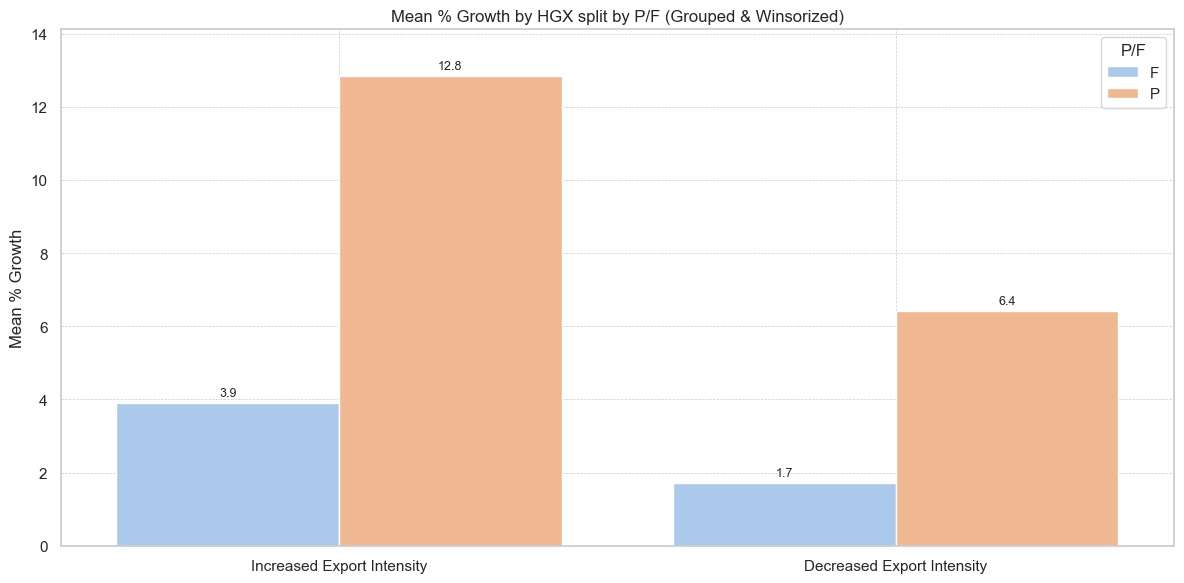

,Group,P/F,Mean % Growth,Median % Growth,Std Dev (pp),Company Count
0,Decreased Export Intensity,F,"1,72","-1,82","36,92",481
1,Decreased Export Intensity,P,"6,42","-0,33","42,84",601
2,Increased Export Intensity,F,"3,91","-2,00","36,66",396
3,Increased Export Intensity,P,"12,83","6,85","39,89",332


In [29]:
# For single or two parameters
plot_growth_barchart(
    df=df_filter[df_filter['Year'] == 2023],
    group_col='HGX',
    hue_col='P/F',
    sort_by='mean',
    log_y=False,
    save=True,
    filename='growth_HGX_by_drop.png'
)

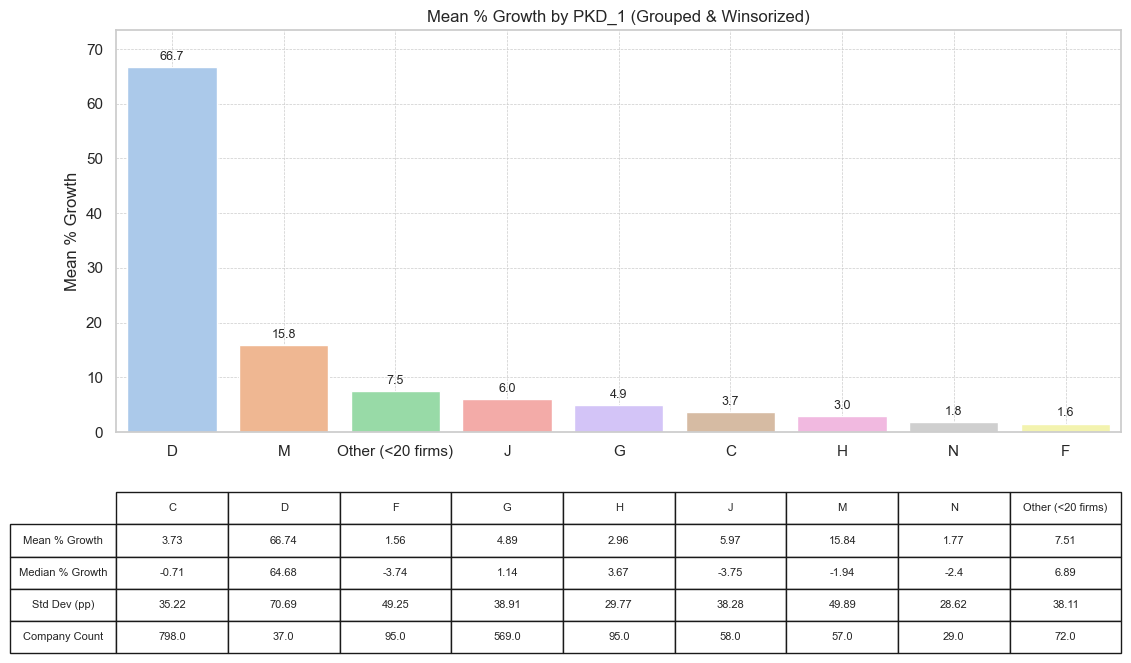

,Group,Mean % Growth,Median % Growth,Std Dev (pp),Company Count
0,C,"3,73","-0,71","35,22",798
1,D,"66,74","64,68","70,69",37
2,F,"1,56","-3,74","49,25",95
3,G,"4,89","1,14","38,91",569
4,H,"2,96","3,67","29,77",95
5,J,"5,97","-3,75","38,28",58
6,M,"15,84","-1,94","49,89",57
7,N,"1,77","-2,40","28,62",29
8,Other (<20 firms),"7,51","6,89","38,11",72


In [21]:
# For PKD_1 mean growth
plot_growth_barchart(
    df=df_filter[df_filter['Year'] == 2023],
    group_col='PKD_1',
    growth_col='RSGrowth_2023_2019',
    sort_by='mean',
    save=True,
    filename='pkd1_mean_growth.png'
)

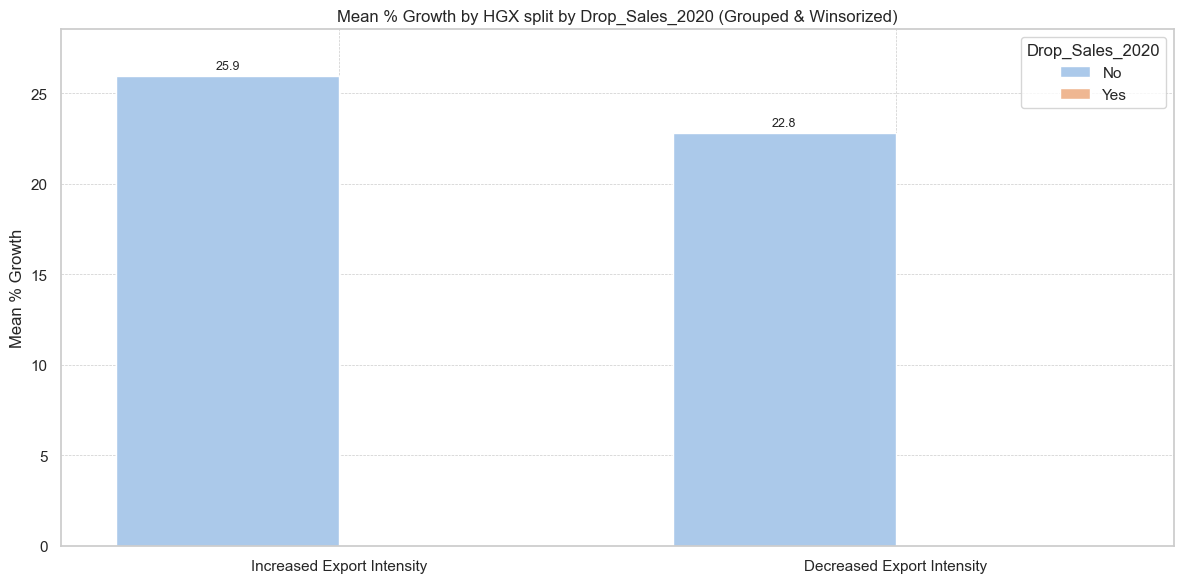

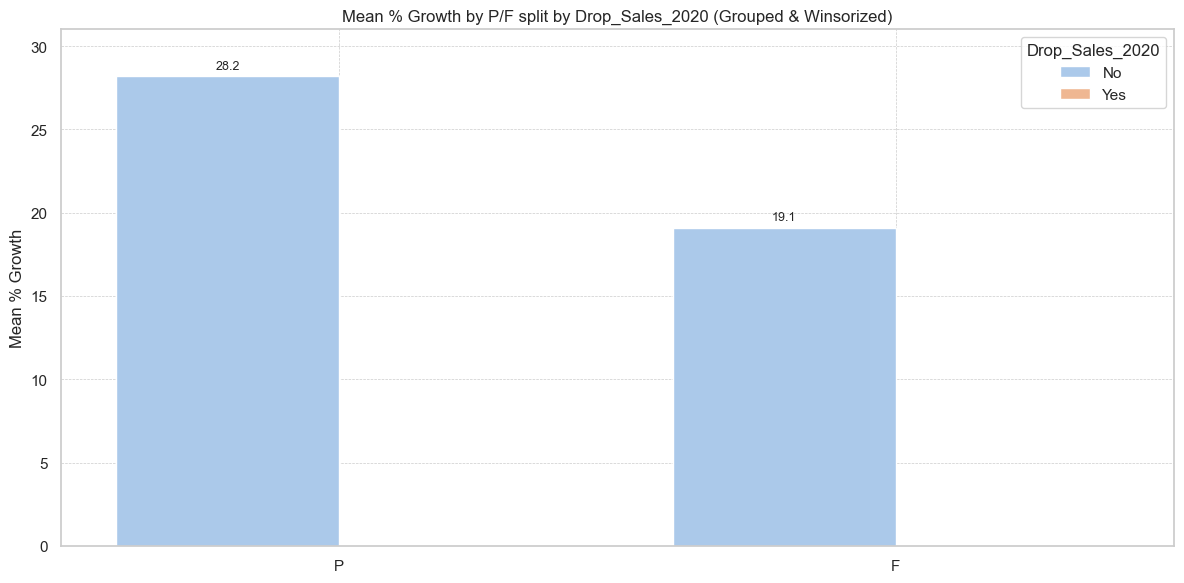

{'HGX':                         Group Drop_Sales_2020  Mean % Growth  Median % Growth  \
 0  Decreased Export Intensity              No          22,78            13,38   
 1  Decreased Export Intensity             Yes          -6,49            -8,52   
 2  Increased Export Intensity              No          25,92            17,23   
 3  Increased Export Intensity             Yes          -3,63            -6,36   
 
    Std Dev (pp)  Company Count  
 0         43,41            400  
 1         34,14            682  
 2         40,55            286  
 3         32,00            442  ,
 'P/F':   Group Drop_Sales_2020  Mean % Growth  Median % Growth  Std Dev (pp)  \
 0     F              No          19,10            11,39         40,03   
 1     F             Yes          -6,21            -8,36         31,55   
 2     P              No          28,18            18,29         43,59   
 3     P             Yes          -4,50            -6,93         35,06   
 
    Company Count  
 0         

In [22]:
# Batch charts + Excel
batch_growth_barcharts(
    df=df_filter[df_filter['Year'] == 2023],
    group_vars=['HGX', 'P/F'],
    hue_col='Drop_Sales_2020',
    growth_col='RSGrowth_2023_2019',
    sort_by='mean',
    save_all=True,
    export_excel=True,
    excel_filename="grouped_by_drop.xlsx"
)

In [23]:
from scipy.stats import pearsonr
df=df_filter[df_filter['Year'] == 2023]
corr_sales_employment, p = pearsonr(df.RSGrowth_2023_2019, df.EGrowth_2023_2019)
print(corr_sales_employment)

0.1421904554062744
